In [226]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report   
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [227]:
df=pd.read_csv('twitter.csv', encoding='latin-1')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         100 non-null    int64  
 1   candidate                  99 non-null     object 
 2   candidate_confidence       100 non-null    float64
 3   relevant_yn                100 non-null    object 
 4   relevant_yn_confidence     100 non-null    float64
 5   sentiment                  100 non-null    object 
 6   sentiment_confidence       100 non-null    float64
 7   subject_matter             98 non-null     object 
 8   subject_matter_confidence  100 non-null    float64
 9   candidate_gold             0 non-null      float64
 10  name                       100 non-null    object 
 11  relevant_yn_gold           0 non-null      float64
 12  retweet_count              100 non-null    int64  
 13  sentiment_gold             0 non-null      float64


In [228]:
df

,id,candidate,candidate_confidence,relevant_yn,relevant_yn_confidence,sentiment,sentiment_confidence,subject_matter,subject_matter_confidence,candidate_gold,...,relevant_yn_gold,retweet_count,sentiment_gold,subject_matter_gold,text,tweet_coord,tweet_created,tweet_id,tweet_location,user_timezone
0,1,No candidate mentioned,1.0000,yes,1.0000,Neutral,0.6578,None of the above,1.0000,NaN,...,NaN,5,NaN,NaN,RT @NancyLeeGrahn: How did everyone feel about...,NaN,07-08-2015 09:54,6.296970e+17,NaN,Quito
1,2,Scott Walker,1.0000,yes,1.0000,Positive,0.6333,None of the above,1.0000,NaN,...,NaN,26,NaN,NaN,RT @ScottWalker: Didn't catch the full #GOPdeb...,NaN,07-08-2015 09:54,6.296970e+17,NaN,NaN
2,3,No candidate mentioned,1.0000,yes,1.0000,Neutral,0.6629,None of the above,0.6629,NaN,...,NaN,27,NaN,NaN,RT @TJMShow: No mention of Tamir Rice and the ...,NaN,07-08-2015 09:54,6.296970e+17,NaN,NaN
3,4,No candidate mentioned,1.0000,yes,1.0000,Positive,1.0000,None of the above,0.7039,NaN,...,NaN,138,NaN,NaN,RT @RobGeorge: That Carly Fiorina is trending ...,NaN,07-08-2015 09:54,6.296970e+17,Texas,Central Time (US & Canada)
4,5,Donald Trump,1.0000,yes,1.0000,Positive,0.7045,None of the above,1.0000,NaN,...,NaN,156,NaN,NaN,RT @DanScavino: #GOPDebate w/ @realDonaldTrump...,NaN,07-08-2015 09:54,6.296970e+17,NaN,Arizona
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Donald Trump,1.0000,yes,1.0000,Negative,0.6659,None of the above,0.6905,NaN,...,NaN,1,NaN,NaN,RT @fl_dreamer: Haha a little saas from @voxdo...,NaN,07-08-2015 09:54,6.296970e+17,191 Throckmorton St. Freehold,NaN
96,97,Jeb Bush,0.4413,yes,0.6643,Neutral,0.3517,None of the above,0.2336,NaN,...,NaN,1,NaN,NaN,"RT @TexasCruzn: RT @AllenWestRepub ""Dear @JebB...",NaN,07-08-2015 09:54,6.296970e+17,TEXAS is the greatest state,Central Time (US & Canada)
97,98,No candidate mentioned,1.0000,yes,1.0000,Negative,1.0000,None of the above,1.0000,NaN,...,NaN,347,NaN,NaN,RT @zellieimani: What people saw in person vs ...,NaN,07-08-2015 09:54,6.296970e+17,"Austin, Texas",NaN
98,99,Marco Rubio,0.4535,yes,0.6734,Negative,0.6734,LGBT issues,0.4535,NaN,...,NaN,9,NaN,NaN,RT @TheBaxterBean: Marco Rubio Told To His Fac...,NaN,07-08-2015 09:54,6.296970e+17,"lib utopia, with unicorns",Pacific Time (US & Canada)


In [229]:
df.describe(include='all')


,id,candidate,candidate_confidence,relevant_yn,relevant_yn_confidence,sentiment,sentiment_confidence,subject_matter,subject_matter_confidence,candidate_gold,...,relevant_yn_gold,retweet_count,sentiment_gold,subject_matter_gold,text,tweet_coord,tweet_created,tweet_id,tweet_location,user_timezone
count,100.000000,99,100.000000,100,100.000000,100,100.000000,98,100.000000,0.0,...,0.0,100.000000,0.0,0.0,100,0.0,100,1.000000e+02,64,70
unique,NaN,11,NaN,1,NaN,3,NaN,10,NaN,NaN,...,NaN,NaN,NaN,NaN,100,NaN,1,NaN,60,12
top,NaN,No candidate mentioned,NaN,yes,NaN,Negative,NaN,None of the above,NaN,NaN,...,NaN,NaN,NaN,NaN,RT @NancyLeeGrahn: How did everyone feel about...,NaN,07-08-2015 09:54,NaN,Los Angeles,Eastern Time (US & Canada)
freq,NaN,55,NaN,100,NaN,60,NaN,59,NaN,NaN,...,NaN,NaN,NaN,NaN,1,NaN,100,NaN,2,21
mean,50.500000,NaN,0.830628,NaN,0.917402,NaN,0.738438,NaN,0.750373,NaN,...,NaN,275.420000,NaN,NaN,NaN,NaN,NaN,6.296970e+17,NaN,NaN
std,29.011492,NaN,0.258954,NaN,0.147993,NaN,0.209101,NaN,0.268338,NaN,...,NaN,848.601335,NaN,NaN,NaN,NaN,NaN,1.286448e+02,NaN,NaN
min,1.000000,NaN,0.224000,NaN,0.618000,NaN,0.326100,NaN,0.224000,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,6.296970e+17,NaN,NaN
25%,25.750000,NaN,0.638600,NaN,1.000000,NaN,0.645800,NaN,0.463000,NaN,...,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,6.296970e+17,NaN,NaN
50%,50.500000,NaN,1.000000,NaN,1.000000,NaN,0.669200,NaN,0.694550,NaN,...,NaN,12.500000,NaN,NaN,NaN,NaN,NaN,6.296970e+17,NaN,NaN
75%,75.250000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN,...,NaN,142.000000,NaN,NaN,NaN,NaN,NaN,6.296970e+17,NaN,NaN


In [230]:
df=df[['sentiment','text']]
df.dropna(inplace=True)



/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_32176/459028992.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [231]:
le=LabelEncoder()
df['sentiment']=le.fit_transform(df['sentiment'])
df

/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_32176/648042106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment']=le.fit_transform(df['sentiment'])


,sentiment,text
0,1,RT @NancyLeeGrahn: How did everyone feel about...
1,2,RT @ScottWalker: Didn't catch the full #GOPdeb...
2,1,RT @TJMShow: No mention of Tamir Rice and the ...
3,2,RT @RobGeorge: That Carly Fiorina is trending ...
4,2,RT @DanScavino: #GOPDebate w/ @realDonaldTrump...
...,...,...
95,0,RT @fl_dreamer: Haha a little saas from @voxdo...
96,1,"RT @TexasCruzn: RT @AllenWestRepub ""Dear @JebB..."
97,0,RT @zellieimani: What people saw in person vs ...
98,0,RT @TheBaxterBean: Marco Rubio Told To His Fac...


In [232]:
print(list(le.classes_))


['Negative', 'Neutral', 'Positive']


In [233]:
X=df['text']
y=df['sentiment']

In [234]:
X

0     RT @NancyLeeGrahn: How did everyone feel about...
1     RT @ScottWalker: Didn't catch the full #GOPdeb...
2     RT @TJMShow: No mention of Tamir Rice and the ...
3     RT @RobGeorge: That Carly Fiorina is trending ...
4     RT @DanScavino: #GOPDebate w/ @realDonaldTrump...
                            ...                        
95    RT @fl_dreamer: Haha a little saas from @voxdo...
96    RT @TexasCruzn: RT @AllenWestRepub "Dear @JebB...
97    RT @zellieimani: What people saw in person vs ...
98    RT @TheBaxterBean: Marco Rubio Told To His Fac...
99    RT @carIisIe: None of them have made Trump loo...
Name: text, Length: 100, dtype: object

In [235]:
y

0     1
1     2
2     1
3     2
4     2
     ..
95    0
96    1
97    0
98    0
99    0
Name: sentiment, Length: 100, dtype: int64

In [236]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train

11    RT @WayneDupreeShow: Just woke up to tweet thi...
47    RT @philstockworld: From our Live Chat Room: #...
85    RT @bruneski: Was upstairs putting the kids to...
28    RT @mch7576: RT â@TeaTraitors: #GOPDebate wa...
93    RT @Reince: Simply incredible. http://t.co/apX...
                            ...                        
60    RT @P0TUS: #GOPDebate closing statements: http...
71    RT @HlLLARY: Oh, one more thing. Did anyone he...
14    RT @pattonoswalt: I loved Scott Walker as Mark...
92    RT @MelissaGracey: Credit for this joke goes t...
51    RT @megynkelly: .@ChrisStirewalt: Big moments ...
Name: text, Length: 70, dtype: object

In [237]:
X_test

83    RT @tedcruz: If elected, on my first day as Pr...
53    @rushlimbaugh Americans getting beheaded overs...
70    Fox News Had Its Own #GOPDebate Agenda: Promot...
45    RT @LeKarmaSucre: How the #GOPDebate handled #...
44    Trump thinks criticism of his misogynistic rem...
39    RT @itsashlyperez: listening to fetty wap whil...
22    RT @erinmallorylong: No *I* hate Planned Paren...
80    RT @lolhayley: "The purpose of the military is...
10    @JGreenDC @realDonaldTrump In all fairness #Bi...
0     RT @NancyLeeGrahn: How did everyone feel about...
18    reason comment is funny 'in case you're ignora...
30    @fbhw they're going to need to borrow the trai...
73    @marthamaccallum @billhemmer #gopdebate Bill a...
33    #SocialMedia: The First #GOPDebate: Social Med...
90    Even though she's a super conservative reporte...
4     RT @DanScavino: #GOPDebate w/ @realDonaldTrump...
76    RT @SnarkyDemo: #DonaldTrump said heâs not â...
77    RT @Bipartisanism: A message to the #GOPDe

In [238]:
vectorizer = CountVectorizer()
X_train_vec=vectorizer.fit_transform(X_train)
X_test_vec=vectorizer.transform(X_test)
X_train_vec.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70, 647))

In [239]:
model=MultinomialNB()
model.fit(X_train_vec,y_train)
y_pred=model.predict(X_test_vec)

In [240]:
y_pred

array([2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [241]:
accuracy=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
print('Accuracy:',accuracy)
print('Classification_report:',report)

Accuracy: 0.8
Classification_report:               precision    recall  f1-score   support

           0       0.78      1.00      0.88        21
           1       1.00      0.20      0.33         5
           2       1.00      0.50      0.67         4

    accuracy                           0.80        30
   macro avg       0.93      0.57      0.62        30
weighted avg       0.84      0.80      0.76        30



In [242]:
positive = df[df['sentiment'] == 2]['text']
negative = df[df['sentiment'] == 1]['text']
neutral = df[df['sentiment'] == 0]['text']
positive.shape

(20,)

Text(0.5, 1.0, 'Word Cloud for positive sentimenta')

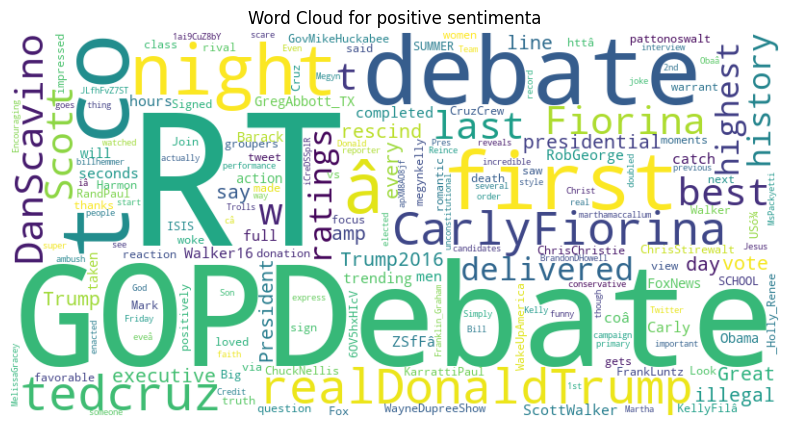

In [243]:
positive_wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(positive))
plt.figure(figsize=(10, 5))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for positive sentimenta')

Text(0.5, 1.0, 'Word Cloud for negative sentiments')

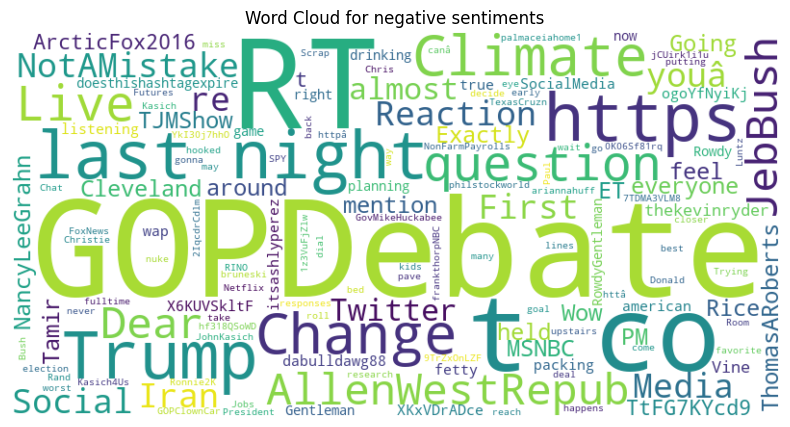

In [244]:
negative_wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(negative))
plt.figure(figsize=(10, 5))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for negative sentiments')

Text(0.5, 1.0, 'Word Cloud for neutral sentiments')

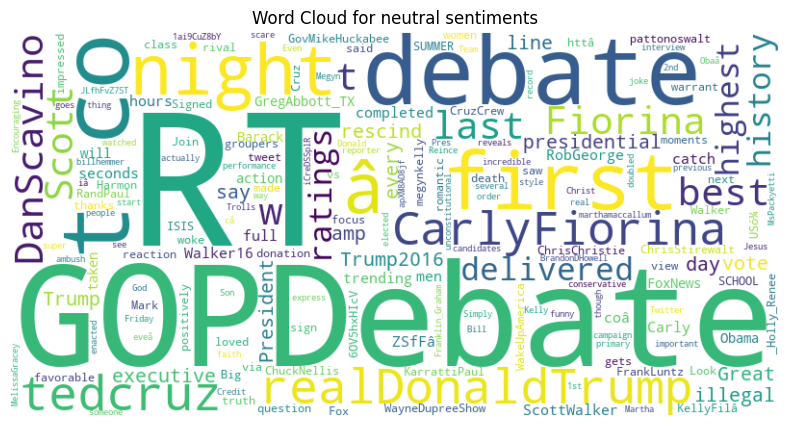

In [245]:
neutral_wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(neutral))
plt.figure(figsize=(10, 5))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for neutral sentiments')